### Training For Baseline Without Optimizer

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Import model, modelIO
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE
from src.model.lstm_bidirectional import BiLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.model.lstm_peephole import PeepholeLSTMModelGPUOptimized
from src.utils.model_io import save_model, load_and_build_model

# Model registry untuk loop experiments
MODEL_REGISTRY = {
    'Optimized': LSTMModelGPUOptimized,
    'BiDirectional': BiLSTMModelGPUOptimized,
    'Nested': NestedLSTMModelGPUOptimized,
    'Peephole': PeepholeLSTMModelGPUOptimized
}

# Export path
CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/lstm_optimized.pkl')
print(CHECKPOINT_PATH)
print(f"📦 Available models: {list(MODEL_REGISTRY.keys())}")

✅ CuPy detected - Using GPU acceleration
✅ CuPy detected - Using GPU acceleration
c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_optimized.pkl
📦 Available models: ['Optimized', 'BiDirectional', 'Nested', 'Peephole']


In [2]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [3]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

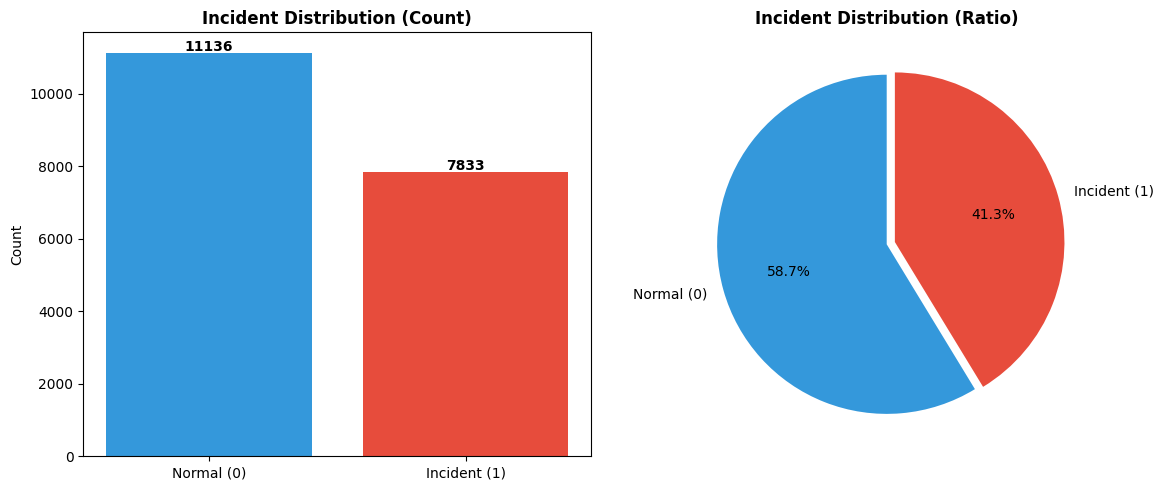


📊 Summary:
   Normal (0): 11,136 (58.7%)
   Incident (1): 7,833 (41.3%)
   Ratio: 1 : 1.4


In [4]:
# === 2.1 Check incident feature ratio ===
# Count values
counts = df['incident'].value_counts()
labels = ['Normal (0)', 'Incident (1)']
# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
axes[0].bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=['#3498db', '#e74c3c'])
axes[0].set_title('Incident Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
# Pie chart
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=labels, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c'], explode=(0, 0.05), startangle=90)
axes[1].set_title('Incident Distribution (Ratio)', fontweight='bold')
plt.tight_layout()
plt.show()
# Print summary
print(f"\n📊 Summary:")
print(f"   Normal (0): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Incident (1): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"   Ratio: 1 : {counts.get(0, 0)/max(counts.get(1, 0), 1):.1f}")

In [5]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)
        

In [ ]:
# === 4. Training ===
def train_eval(X, y, label, model_type='Optimized', cw=1, hidden_size=128, patience=10, epochs=500, batch_size=128, lr=0.001, print_every=1, lambda_l2=0.0001):
    """
    Training and evaluation function with support for different LSTM model types.
    
    Args:
        X: Input features (samples, seq_len, features)
        y: Target labels
        label: Label string for identifying this experiment
        model_type: Type of LSTM model to use. Options:
                   'Optimized' (default), 'BiDirectional', 'Nested', 'Peephole'
        cw: Class weight for positive class
        hidden_size: Number of hidden units
        patience: Early stopping patience
        epochs: Maximum training epochs
        batch_size: Batch size for training
        lr: Learning rate
        print_every: Print metrics every N epochs
        lambda_l2: L2 regularization strength
    
    Returns:
        Dictionary containing metrics and predictions
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Export training, val, test sets
    export_dir = '../data/splits'
    os.makedirs(export_dir, exist_ok=True)
    
    np.save(f'{export_dir}/X_train.npy', X_tr)
    np.save(f'{export_dir}/X_val.npy', X_val)
    np.save(f'{export_dir}/X_test.npy', X_te)
    np.save(f'{export_dir}/y_train.npy', y_tr)
    np.save(f'{export_dir}/y_val.npy', y_val)
    np.save(f'{export_dir}/y_test.npy', y_te)
    print(f"💾 Datasets exported to {export_dir}/")
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Get model class from registry
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model_type: {model_type}. Available: {list(MODEL_REGISTRY.keys())}")
    
    ModelClass = MODEL_REGISTRY[model_type]
    print(f"🔧 Initializing {model_type} LSTM model...")
    
    # Initialize Model with class weight
    model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    
    # Thresholding (Default 0.5)
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save the model parameters
    checkpoint_name = f"lstm_{model_type.lower()}_{label.replace('|', '_').replace('=', '')}.pkl"
    checkpoint_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), checkpoint_name)
    save_model(model, checkpoint_path)
    print(f"💾 Model checkpoint saved to: {checkpoint_path}")
    
    # Calculate metrics and return the requested arrays
    return {
        'Model': label,
        'ModelType': model_type,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'ClassWeight': cw,
        'y_test': y_te,    # Ditambahkan sesuai permintaan
        'y_pred': y_pred,  # Ditambahkan sesuai permintaan
        'y_prob': y_prob   # Bonus: probabilitas mentah untuk analisis threshold nanti
    }

In [7]:
# === 4.1 Save Model Data ===
def save_model_assets(result, output_base_path="../data/output"):
    """
    Saves metrics to CSV and plots (Confusion Matrix & PR-Curve) in a dedicated folder.
    Includes both standard (0.5) and optimized threshold metrics.
    """
    # 1. Create a clean folder name (replacing illegal characters)
    model_name = result['Model']
    folder_name = model_name.replace('|', '_').replace('=', '')
    model_dir = os.path.join(output_base_path, folder_name)
    os.makedirs(model_dir, exist_ok=True)

    # 2. Extract ground truth and probabilities
    y_true = result['y_test']
    y_prob = result['y_prob']
    
    # 3. Find the OPTIMUM Threshold (Maximizing F1-Score)
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    # Calculate F1 for each threshold to find the best balance
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    
    # Handle case where thresholds array is shorter than precisions/recalls
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= opt_threshold).astype(int)
    
    pr_auc = average_precision_score(y_true, y_prob)

    # 4. Visualize and Save PR-Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    baseline = sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.scatter(recalls[opt_idx], precisions[opt_idx], color='black', label=f'Best F1 (T={opt_threshold:.3f})')

    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Purity)')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)

    pr_plot_path = os.path.join(model_dir, f"pr_curve_{folder_name}.png")
    plt.savefig(pr_plot_path, bbox_inches='tight')
    plt.close()

    # 

    # 5. Prepare full metrics for CSV (including Params & Optimized Metrics)
    save_data = {
        'Model': model_name,
        'ROC_AUC': result['AUC'],
        'PR_AUC': pr_auc,
        'TrainingTime': result['TrainingTime'],
        # Standard Metrics (Threshold 0.5)
        'Std_Threshold': 0.5,
        'Std_Accuracy': result['Accuracy'],
        'Std_Precision': result['Precision'],
        'Std_Recall': result['Recall'],
        'Std_F1': result['F1_Score'],
        # Optimized Metrics (Custom Threshold)
        'Opt_Threshold': opt_threshold,
        'Opt_Accuracy': accuracy_score(y_true, y_pred_opt),
        'Opt_Precision': precision_score(y_true, y_pred_opt),
        'Opt_Recall': recall_score(y_true, y_pred_opt),
        'Opt_F1': f1_score(y_true, y_pred_opt),
        # Training Hyperparameters
        'Epochs': 100, 
        'Batch_Size': 128,
        'LR': 0.001,
        'Optimizer': 'SGD'
    }

    # Save CSV
    csv_path = os.path.join(model_dir, f"metrics_{folder_name}.csv")
    pd.DataFrame([save_data]).to_csv(csv_path, index=False)

    # 6. Generate and Save Optimized Confusion Matrix Plot
    plt.figure(figsize=(8, 6))
    cm_opt = confusion_matrix(y_true, y_pred_opt)
    sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Normal', 'Incident'], 
                yticklabels=['Normal', 'Incident'])
    
    plt.title(f"Optimized Confusion Matrix (T={opt_threshold:.3f})\nF1: {f1_score(y_true, y_pred_opt):.4f} | PR-AUC: {pr_auc:.4f}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    plot_path = os.path.join(model_dir, f"cm_opt_{folder_name}.png")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.close() # Free up memory

    print(f"      ✅ Saved assets to: {model_dir}")


Sampling Period: 30min

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480

    🧠 Model Type: Optimized
      → Running SMOTE with Optimized...
💾 Datasets exported to ../data/splits/
🔧 Initializing Optimized LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5968 | Val Loss: 0.5595 | Val Acc: 0.6754 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5717 | Val Loss: 0.5533 | Val Acc: 0.6977 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5611 | Val Loss: 0.5447 | Val Acc: 0.6853 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.5557 | Val Loss: 0.5406 | Val Acc: 0.7164 [UNDERFITTING]
Epoch    5/500 | Train Loss: 0.5505 | Val Loss: 0.5391 | Val Acc: 0.6855 [UNDERFITTING]
Epoch    6/500 | Train Loss: 0.5437 | Val Loss: 0.5340 | Val Acc: 0.7023 [UNDERFITTING]
Epoch    7/500 | Train Loss: 0.5411 | Val L

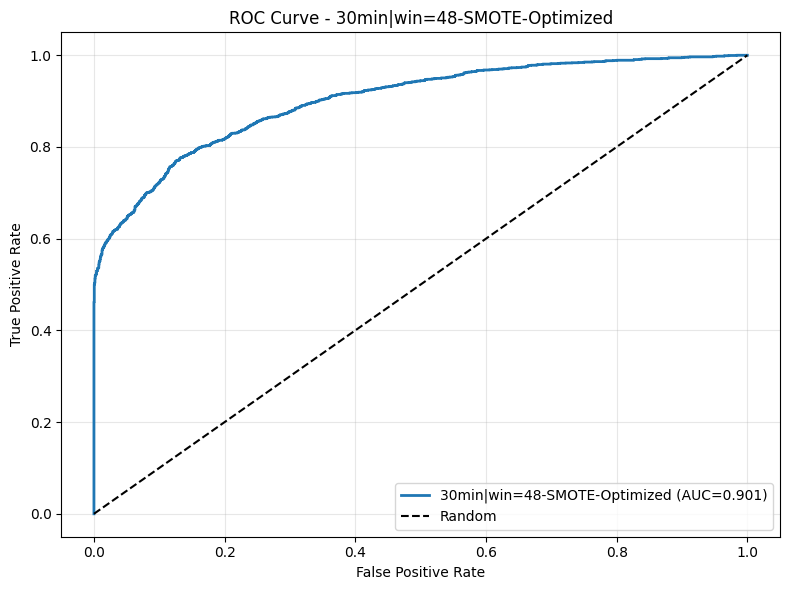

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_optimized_30min_win48-SMOTE-Optimized.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_optimized_30min_win48-SMOTE-Optimized.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-Optimized

    🧠 Model Type: BiDirectional
      → Running SMOTE with BiDirectional...
💾 Datasets exported to ../data/splits/
🔧 Initializing BiDirectional LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5844 | Val Loss: 0.5483 | Val Acc: 0.6972 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5558 | Val Loss: 0.5477 | Val Acc: 0.6667 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5478 | Val Loss: 0.5292 

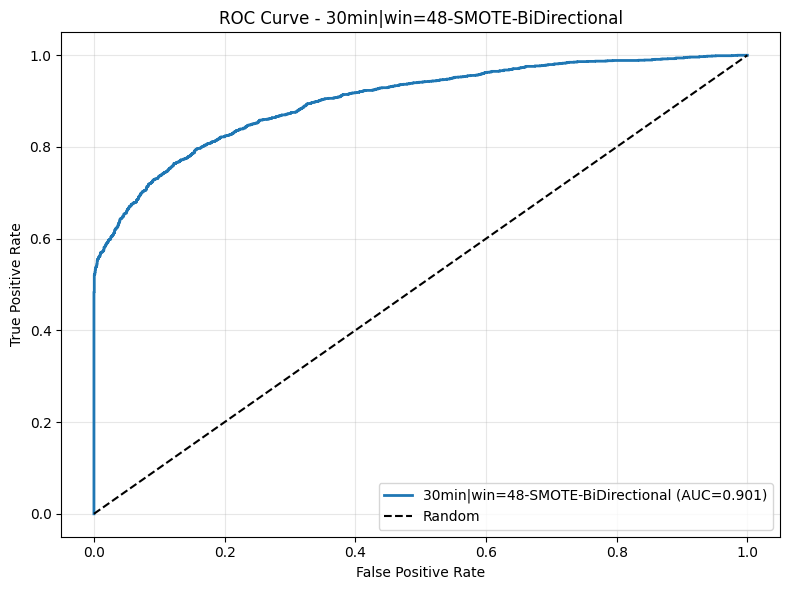

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_bidirectional_30min_win48-SMOTE-BiDirectional.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_bidirectional_30min_win48-SMOTE-BiDirectional.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-BiDirectional

    🧠 Model Type: Nested
      → Running SMOTE with Nested...
💾 Datasets exported to ../data/splits/
🔧 Initializing Nested LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5915 | Val Loss: 0.5588 | Val Acc: 0.6425 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5627 | Val Loss: 0.5425 | Val Acc: 0.6979 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5516 | Val Loss: 0.5347 |

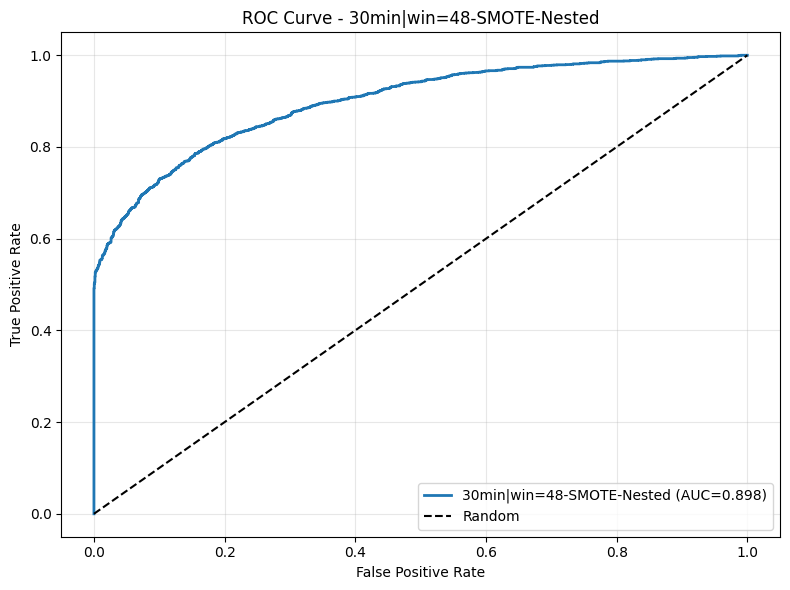

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_nested_30min_win48-SMOTE-Nested.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_nested_30min_win48-SMOTE-Nested.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-Nested

    🧠 Model Type: Peephole
      → Running SMOTE with Peephole...
💾 Datasets exported to ../data/splits/
🔧 Initializing Peephole LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5922 | Val Loss: 0.5680 | Val Acc: 0.6742 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5641 | Val Loss: 0.5600 | Val Acc: 0.6549 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5563 | Val Loss: 0.5345 | Val Acc: 0.6991 [UNDERFITTIN

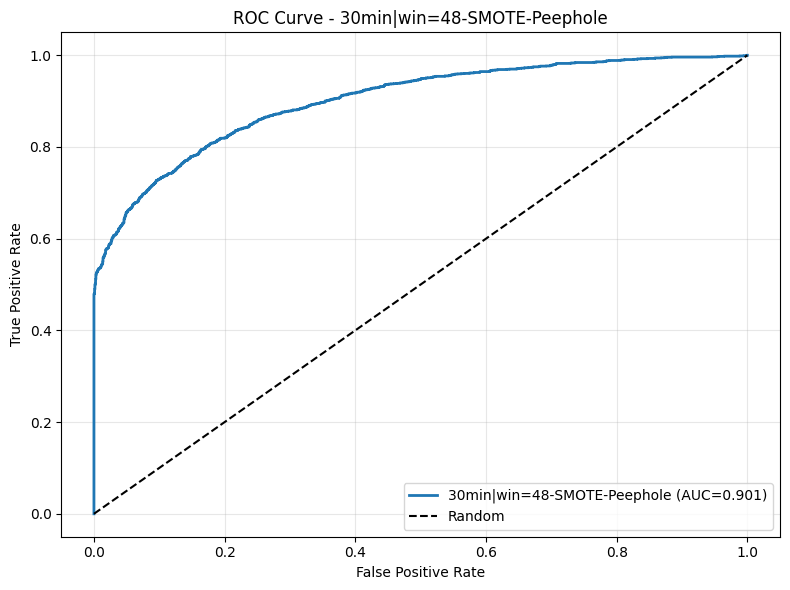

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_peephole_30min_win48-SMOTE-Peephole.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_peephole_30min_win48-SMOTE-Peephole.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-Peephole

✅ Experiment completed! Total results: 4
   Models tested: ['Optimized', 'BiDirectional', 'Nested', 'Peephole']
   Results per model type: 1


In [11]:
# === 5. Run Experiment ==
sampling_periods = ['30min']
window_sizes = [48]
model_types = list(MODEL_REGISTRY.keys())  # ['Optimized', 'BiDirectional', 'Nested', 'Peephole']
results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg({'incident': 'sum', 'Priority': 'mean', 'Impact': 'mean'})
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, ['Priority', 'Impact'], 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        # === Loop through all model types ===
        for model_type in model_types:
            print(f"\n    {'='*50}")
            print(f"    🧠 Model Type: {model_type}")
            print(f"    {'='*50}")

            # # 1. Undersampling
            # if len(maj) >= len(min_class):
            #     maj_down = resample(maj, replace=False, n_samples=len(min_class), random_state=42)
            #     under = pd.concat([maj_down, min_class])
            #     Xu = under.drop('label', axis=1).values.reshape((-1, win, 2))
            #     yu = under.label.values
                
            #     print(f"      → Running Undersampling with {model_type}...")
            #     result = train_eval(Xu, yu, label=f"{sp}|win={win}-Undersampled-{model_type}", model_type=model_type)
            #     results_all.append(result)
            #     save_model_assets(result)

            # 2. SMOTE
            try:
                print(f"      → Running SMOTE with {model_type}...")
                X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
                Xs = X_sm.reshape((-1, win, 2))
                result = train_eval(Xs, y_sm, label=f"{sp}|win={win}-SMOTE-{model_type}", model_type=model_type)
                results_all.append(result)
                save_model_assets(result) 
            except Exception as e:
                print(f"      ✗ SMOTE failed for {model_type}: {e}")
                continue

            # 3. Class Weight (weighted loss on original imbalanced data)
            # cw_vals = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
            # cw_ratio = cw_vals[1] / cw_vals[0]  # Relative weight for class 1
            # print(f"      → Running Class Weight ({cw_ratio:.2f}x) with {model_type}...")
            # result = train_eval(X, y, label=f"{sp}|win={win}-ClassWeight-{model_type}", model_type=model_type, cw=cw_ratio)
            # results_all.append(result)
            # save_model_assets(result)


print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print(f"   Models tested: {model_types}")
print(f"   Results per model type: {len(results_all) // len(model_types) if results_all else 0}")
print('='*60)


📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)


,Model,ModelType,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
0,30min|win=48-SMOTE-Optimized,Optimized,0.8215,0.8583,0.7700,0.8118,0.9012,3071.7298
1,30min|win=48-SMOTE-BiDirectional,BiDirectional,0.8168,0.8431,0.7784,0.8095,0.9011,5308.3877
2,30min|win=48-SMOTE-Peephole,Peephole,0.8143,0.8505,0.7626,0.8042,0.9005,2644.9572
3,30min|win=48-SMOTE-Nested,Nested,0.8143,0.8529,0.7596,0.8036,0.8980,2923.1629



📈 SUMMARY BY MODEL TYPE (Mean Metrics)


,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
ModelType,,,,,,
BiDirectional,0.8168,0.8431,0.7784,0.8095,0.9011,5308.3877
Nested,0.8143,0.8529,0.7596,0.8036,0.8980,2923.1629
Optimized,0.8215,0.8583,0.7700,0.8118,0.9012,3071.7298
Peephole,0.8143,0.8505,0.7626,0.8042,0.9005,2644.9572



🎯 DETAILED ANALYSIS: 30min|win=48-SMOTE-Optimized
   Model Type: Optimized


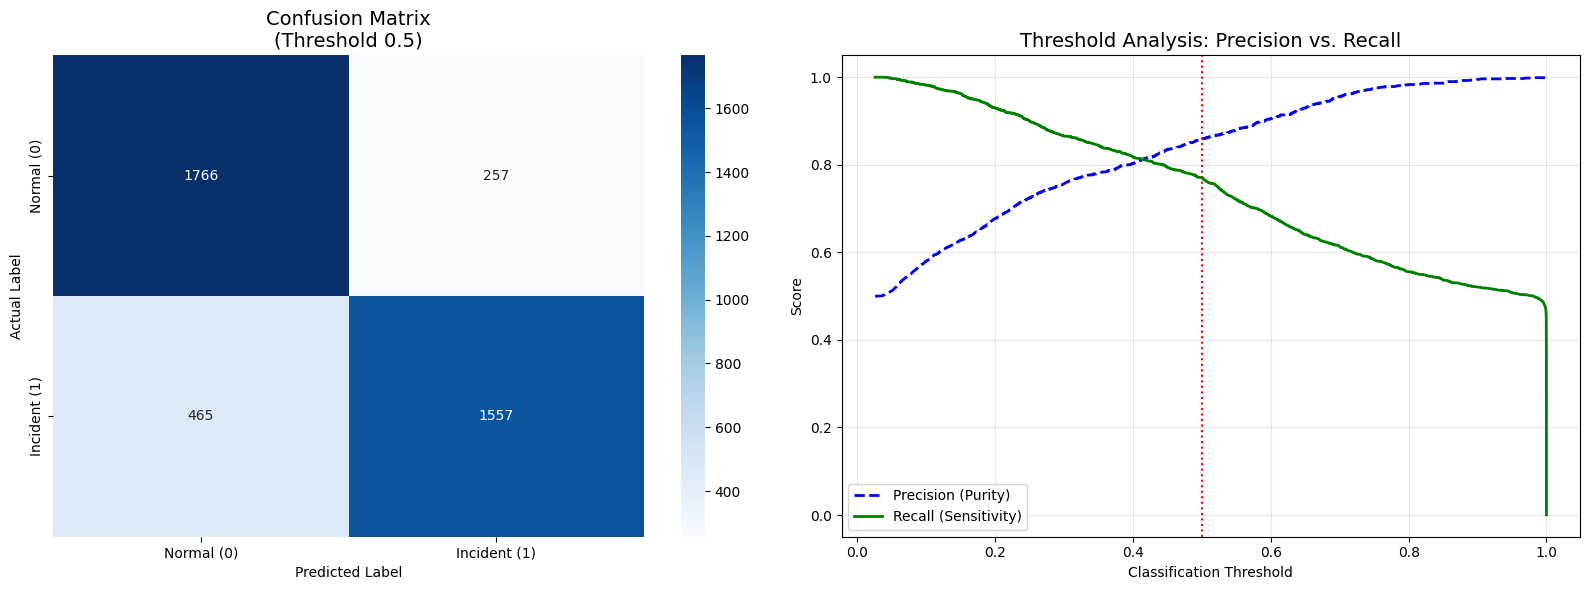

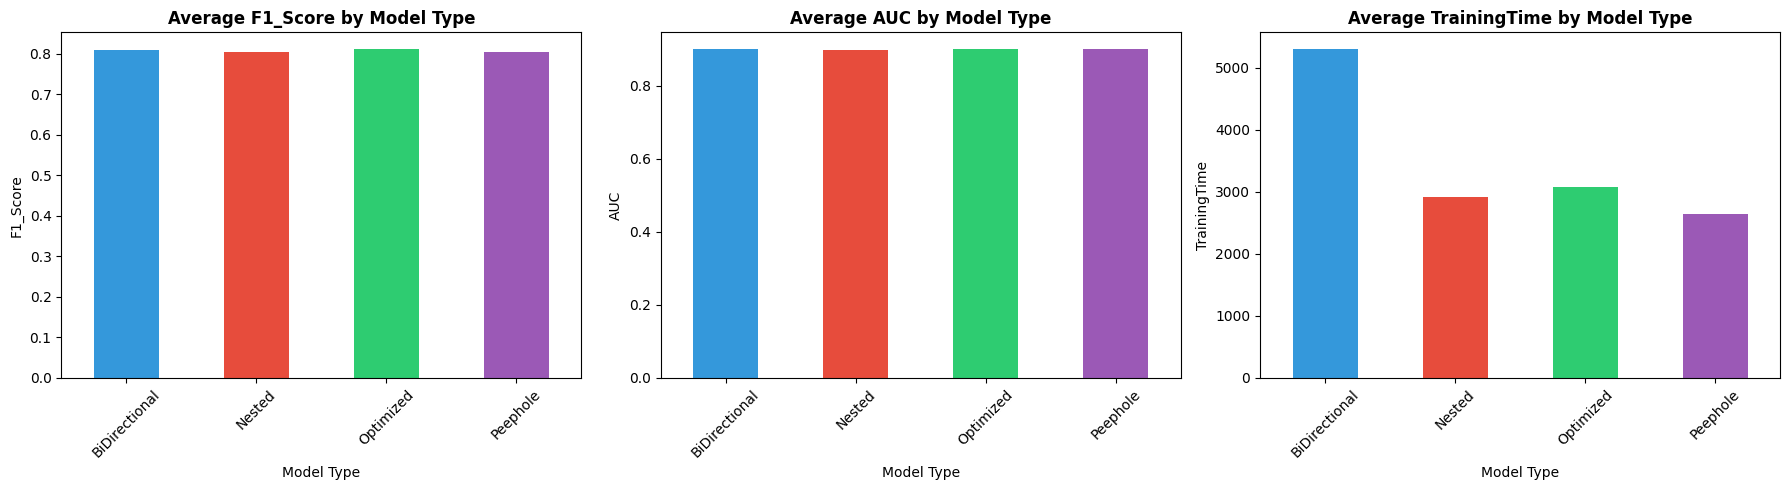


💡 RESOURCE OPTIMIZATION TIP:
   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: 0.393
   Pada titik ini, Precision akan berada di atas 80% dengan Recall sekitar 82.3%.


In [12]:
# === 6. Final Results Visualization & Comparison ===

# 1. Convert the results list to a Pandas DataFrame
res_df = pd.DataFrame(results_all)

# 2. Metadata Extraction
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].fillna(0).astype(int)
res_df['Sampling'] = res_df['Sampling'].fillna('Unknown')

# Identify Method and Type
res_df['Method'] = res_df['Model'].apply(lambda m: 'SMOTE' if 'SMOTE' in m else ('Undersampled' if 'Under' in m else ('ClassWeight' if 'ClassWeight' in m else 'Original')))

# Sort by F1_Score or AUC to find the best model for detailed analysis
res_df = res_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# --- A. Comparative Summary Table ---
print("\n" + "="*90)
print("📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)")
print("="*90)
display(res_df[['Model', 'ModelType', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].round(4))

# --- A.1 Summary by Model Type ---
print("\n" + "="*90)
print("📈 SUMMARY BY MODEL TYPE (Mean Metrics)")
print("="*90)
model_summary = res_df.groupby('ModelType')[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].mean()
display(model_summary.round(4))

# --- B. Detailed Analysis for the BEST MODEL ---
# Ambil data dari model peringkat pertama (Best Model)
best_model_data = res_df.iloc[0]
y_true = best_model_data['y_test']
y_pred = best_model_data['y_pred']
y_prob = best_model_data['y_prob']
model_label = best_model_data['Model']
model_type = best_model_data['ModelType']

print("\n" + "="*90)
print(f"🎯 DETAILED ANALYSIS: {model_label}")
print(f"   Model Type: {model_type}")
print("="*90)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Incident (1)'],
            yticklabels=['Normal (0)', 'Incident (1)'], ax=ax[0])
ax[0].set_title(f"Confusion Matrix\n(Threshold 0.5)", fontsize=14)
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# 2. Threshold Analysis (Precision vs. Recall Trade-off)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

ax[1].plot(thresholds, precisions[:-1], "b--", label="Precision (Purity)", linewidth=2)
ax[1].plot(thresholds, recalls[:-1], "g-", label="Recall (Sensitivity)", linewidth=2)
ax[1].set_xlabel("Classification Threshold")
ax[1].set_ylabel("Score")
ax[1].set_title("Threshold Analysis: Precision vs. Recall", fontsize=14)
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Tambahkan garis bantu untuk melihat dampak terhadap False Positive (Precision)
# Sesuai kebutuhan Anda: meminimalkan False Positive = Mengejar Precision Tinggi
ax[1].axvline(x=0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
plt.tight_layout()
plt.show()

# --- C. Model Type Performance Comparison Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['F1_Score', 'AUC', 'TrainingTime']

for idx, metric in enumerate(metrics_to_plot):
    model_summary[metric].plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    axes[idx].set_title(f'Average {metric} by Model Type', fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel('Model Type')
    axes[idx].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

# --- D. Threshold Optimization for Resource Efficiency ---
# Mencari threshold terbaik jika ingin Precision > 0.8 (Hemat Resource)
target_precision = 0.80
idx = np.where(precisions >= target_precision)[0]

if len(idx) > 0:
    opt_threshold = thresholds[idx[0]]
    opt_recall = recalls[idx[0]]
    print(f"\n💡 RESOURCE OPTIMIZATION TIP:")
    print(f"   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: {opt_threshold:.3f}")
    print(f"   Pada titik ini, Precision akan berada di atas {target_precision*100:.0f}% dengan Recall sekitar {opt_recall*100:.1f}%.")
else:
    print("\n[Notice]: Tidak ditemukan threshold yang mencapai target Precision tersebut.")